Successfully loaded 'salary_dataset.csv'.

Dataset head:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Starting hyperparameter tuning...
...Tuning complete.

--- Best Model Results ---
Best Learning Rate (alpha): 0.1
Best Number of Epochs: 100
Model R-squared value: 0.9570

Final Model (on scaled data): y = 26367.18 * X_scaled + 76003.00

Saved plot: 'cost_vs_epoch.png'
Saved plot: 'regression_plot.png'


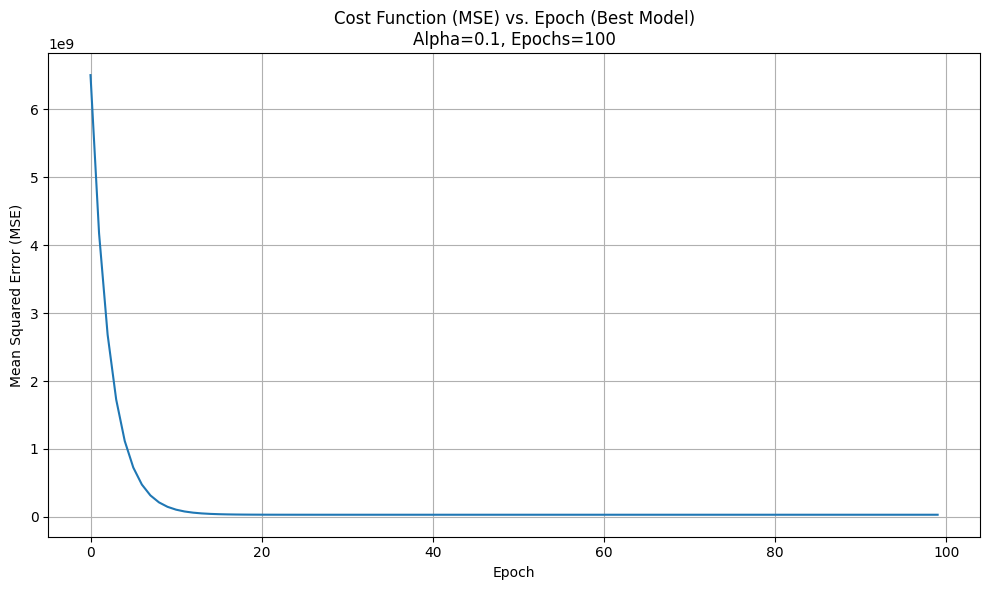

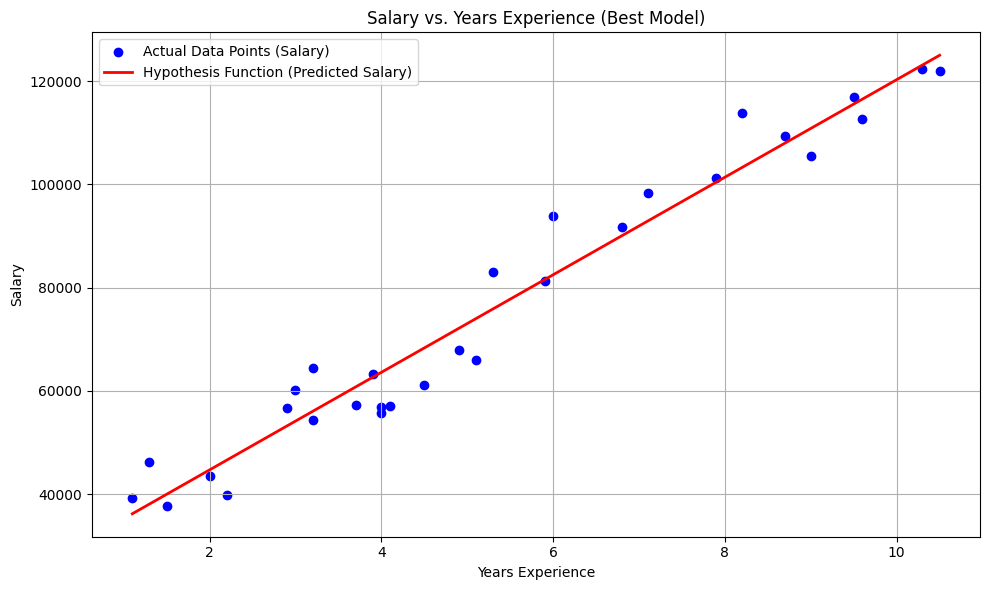

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('salary_dataset.csv')
    print("Successfully loaded 'salary_dataset.csv'.")
except FileNotFoundError:
    print("Warning: 'salary_dataset.csv' not found.")
    print("Using a sample dataset to proceed with the demonstration.")
    data = {
        'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
        'Salary': [39343.0, 46205.0, 37731.0, 43525.0, 39891.0, 56642.0, 60150.0, 54445.0, 64445.0, 57189.0, 63218.0, 55794.0, 56957.0, 57081.0, 61111.0, 67938.0, 66029.0, 83088.0, 81363.0, 93940.0, 91738.0, 98273.0, 101302.0, 113812.0, 109431.0, 105582.0, 116969.0, 112635.0, 122391.0, 121872.0]
    }
    df = pd.DataFrame(data)

print("\nDataset head:")
print(df.head())

X_orig = df['YearsExperience'].values
y = df['Salary'].values

X_mean = np.mean(X_orig)
X_std = np.std(X_orig)

if X_std == 0:
    X_std = 1

X_scaled = (X_orig - X_mean) / X_std

N = len(y)

def r2_score_manual(y_true, y_pred):
    """Calculates R-squared value from scratch."""
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)

    if ss_total == 0:
        return 1.0 if ss_residual == 0 else 0.0

    r2 = 1 - (ss_residual / ss_total)
    return r2

print("\nStarting hyperparameter tuning...")

learning_rates = [0.1, 0.01, 0.001]
num_epochs_list = [100, 500, 1000]

best_r2 = -np.inf
best_params = {}
best_cost_history = []
best_model = {}

for alpha in learning_rates:
    for epochs in num_epochs_list:

        m = 0.0
        c = 0.0
        cost_history = []

        for i in range(epochs):
            y_pred = m * X_scaled + c

            cost = (1/N) * np.sum((y - y_pred) ** 2)
            cost_history.append(cost)

            dm = (-2/N) * np.sum(X_scaled * (y - y_pred))

            dc = (-2/N) * np.sum(y - y_pred)

            m = m - alpha * dm
            c = c - alpha * dc

        final_y_pred = m * X_scaled + c
        current_r2 = r2_score_manual(y, final_y_pred)

        if current_r2 > best_r2:
            best_r2 = current_r2
            best_params = {'alpha': alpha, 'epochs': epochs}
            best_model = {'m': m, 'c': c}
            best_cost_history = cost_history

print("...Tuning complete.")

print("\n--- Best Model Results ---")
print(f"Best Learning Rate (alpha): {best_params['alpha']}")
print(f"Best Number of Epochs: {best_params['epochs']}")
print(f"Model R-squared value: {best_r2:.4f}")

m_best = best_model['m']
c_best = best_model['c']

print(f"\nFinal Model (on scaled data): y = {m_best:.2f} * X_scaled + {c_best:.2f}")

y_pred_line = m_best * X_scaled + c_best

plt.figure(figsize=(10, 6))
plt.plot(range(best_params['epochs']), best_cost_history)
plt.title(f'Cost Function (MSE) vs. Epoch (Best Model)\nAlpha={best_params["alpha"]}, Epochs={best_params["epochs"]}')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.tight_layout()
plt.savefig('cost_vs_epoch.png')
print("\nSaved plot: 'cost_vs_epoch.png'")

sorted_indices = np.argsort(X_orig)
X_plot = X_orig[sorted_indices]
y_plot = y_pred_line[sorted_indices]

plt.figure(figsize=(10, 6))
plt.scatter(X_orig, y, color='blue', label='Actual Data Points (Salary)')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Hypothesis Function (Predicted Salary)')
plt.title('Salary vs. Years Experience (Best Model)')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('regression_plot.png')
print("Saved plot: 'regression_plot.png'")